# EDA – Spotify Tracks Dataset
**Evaluación Parcial N°3 – ITY1101 Gestión de Datos para IA**  
**Docente: Felipe Eduardo Zambrano Bigiarini**  
**Integrantes: Omar Bravo, Sebastián Caamaño, Vicente Órdenes**  

## 1. Carga e inspección inicial del dataset

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    roc_curve, auc, roc_auc_score
)
import warnings
warnings.filterwarnings('ignore')

matplotlib.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid', palette='muted')

# -------------------------------------------------------------------
# NOTA: Descarga el dataset desde Kaggle antes de ejecutar este notebook:
# https://www.kaggle.com/datasets/yashdev01/spotify-tracks-dataset
# Guarda el archivo como 'spotify-tracks-dataset.csv' en el mismo directorio.
# -------------------------------------------------------------------
df = pd.read_csv('spotify-tracks-dataset.csv')
print(f'Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}')
df.head()

Filas: 114,000 | Columnas: 22


,Unnamed: 0.1,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [27]:
# Información general del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 22 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0.1      114000 non-null  int64  
 1   Unnamed: 0        114000 non-null  int64  
 2   track_id          114000 non-null  object 
 3   artists           113999 non-null  object 
 4   album_name        113999 non-null  object 
 5   track_name        113999 non-null  object 
 6   popularity        114000 non-null  int64  
 7   duration_ms       114000 non-null  int64  
 8   explicit          114000 non-null  bool   
 9   danceability      114000 non-null  float64
 10  energy            114000 non-null  float64
 11  key               114000 non-null  int64  
 12  loudness          114000 non-null  float64
 13  mode              114000 non-null  int64  
 14  speechiness       114000 non-null  float64
 15  acousticness      114000 non-null  float64
 16  instrumentalness  11

## 2. Análisis de calidad de datos

In [28]:
# Valores nulos por columna
nulos = df.isnull().sum()
pct_nulos = (nulos / len(df) * 100).round(2)
reporte_nulos = pd.DataFrame({'Nulos': nulos, '% del total': pct_nulos})
print('=== Valores nulos por columna ===')
print(reporte_nulos[reporte_nulos['Nulos'] > 0])

# Duplicados
dup = df.duplicated().sum()
print(f'\nRegistros duplicados (filas completas): {dup:,}')

# Duplicados por track_id
dup_id = df.duplicated(subset='track_id').sum()
print(f'Duplicados por track_id: {dup_id:,}')

=== Valores nulos por columna ===
            Nulos  % del total
artists         1          0.0
album_name      1          0.0
track_name      1          0.0

Registros duplicados (filas completas): 0
Duplicados por track_id: 24,259


In [29]:
# Estadísticas descriptivas de variables numéricas
numericas = ['popularity','duration_ms','danceability','energy','loudness',
             'speechiness','acousticness','instrumentalness','liveness',
             'valence','tempo']
df[numericas].describe().round(3)

,popularity,duration_ms,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
count,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000
mean,33.239,228029.153,0.567,0.641,-8.259,0.085,0.315,0.156,0.214,0.474,122.148
std,22.305,107297.713,0.174,0.252,5.029,0.106,0.333,0.310,0.190,0.259,29.978
min,0.000,0.000,0.000,0.000,-49.531,0.000,0.000,0.000,0.000,0.000,0.000
25%,17.000,174066.000,0.456,0.472,-10.013,0.036,0.017,0.000,0.098,0.260,99.219
50%,35.000,212906.000,0.580,0.685,-7.004,0.049,0.169,0.000,0.132,0.464,122.017
75%,50.000,261506.000,0.695,0.854,-5.003,0.084,0.598,0.049,0.273,0.683,140.071
max,100.000,5237295.000,0.985,1.000,4.532,0.965,0.996,1.000,1.000,0.995,243.372


## 3. Preprocesamiento y limpieza

In [30]:
# Eliminar duplicados completos
df = df.drop_duplicates()

# Eliminar duplicados por track_id (conservar primera aparición)
df = df.drop_duplicates(subset='track_id', keep='first')

# Eliminar filas con nulos en columnas clave
cols_clave = ['artists','album_name','track_name','track_genre']
df = df.dropna(subset=cols_clave)

# Convertir duration de ms a minutos
df['duration_min'] = (df['duration_ms'] / 60000).round(2)

# Crear variable binaria de popularidad (popular si >= 50)
df['popular'] = (df['popularity'] >= 50).astype(int)

# Convertir explicit a entero
df['explicit'] = df['explicit'].astype(int)

print(f'Registros tras limpieza: {len(df):,}')
print(f'Canciones populares (popularity >= 50): {df["popular"].sum():,} ({df["popular"].mean()*100:.1f}%)')

Registros tras limpieza: 89,740
Canciones populares (popularity >= 50): 21,209 (23.6%)


## 4. Análisis univariado

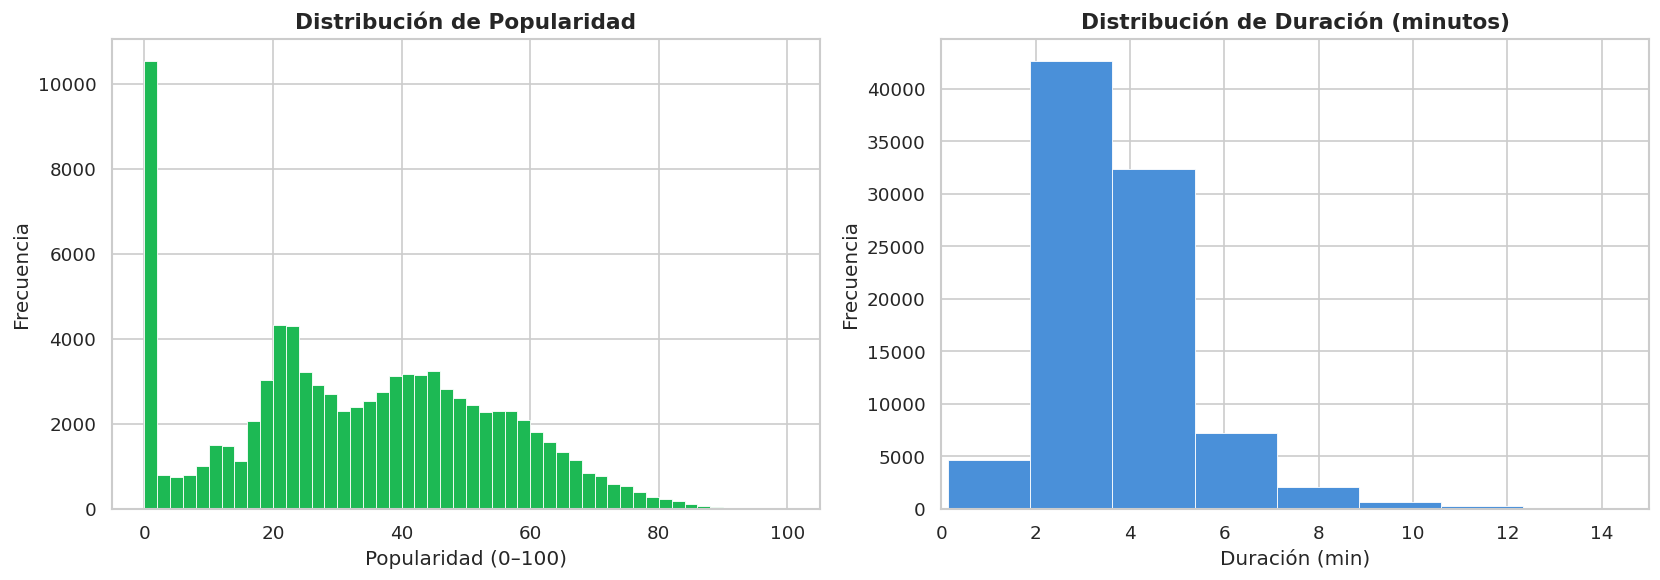

In [31]:
# Distribución de popularidad
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['popularity'], bins=50, color='#1DB954', edgecolor='white', linewidth=0.5)
axes[0].set_title('Distribución de Popularidad', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Popularidad (0–100)')
axes[0].set_ylabel('Frecuencia')

axes[1].hist(df['duration_min'], bins=50, color='#4A90D9', edgecolor='white', linewidth=0.5)
axes[1].set_title('Distribución de Duración (minutos)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Duración (min)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_xlim(0, 15)

plt.tight_layout()
plt.savefig('fig1_distribuciones.png', bbox_inches='tight')
plt.show()

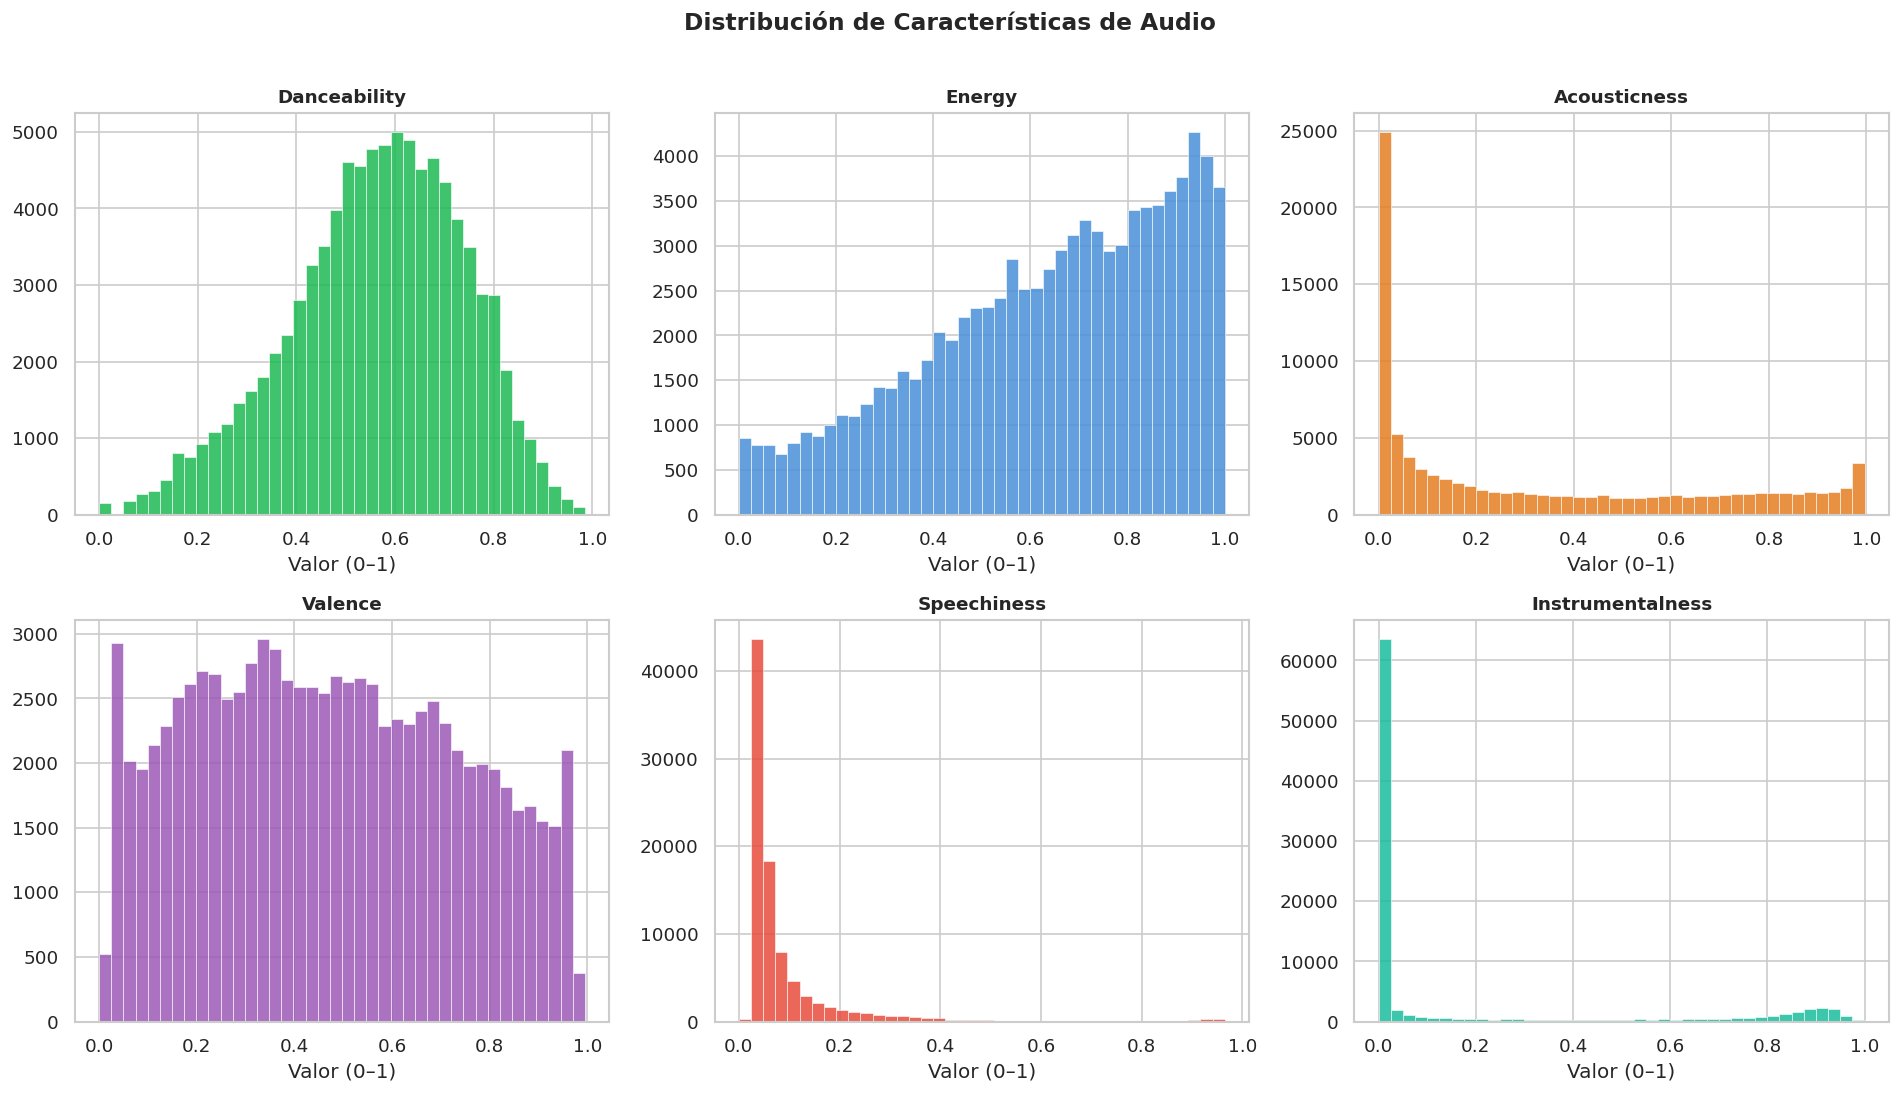

In [32]:
# Distribución de variables de audio
audio_vars = ['danceability','energy','acousticness','valence','speechiness','instrumentalness']
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

colors = ['#1DB954','#4A90D9','#E67E22','#9B59B6','#E74C3C','#1ABC9C']
for i, (var, color) in enumerate(zip(audio_vars, colors)):
    axes[i].hist(df[var], bins=40, color=color, edgecolor='white', linewidth=0.4, alpha=0.85)
    axes[i].set_title(var.capitalize(), fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Valor (0–1)')

plt.suptitle('Distribución de Características de Audio', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig2_audio_vars.png', bbox_inches='tight')
plt.show()

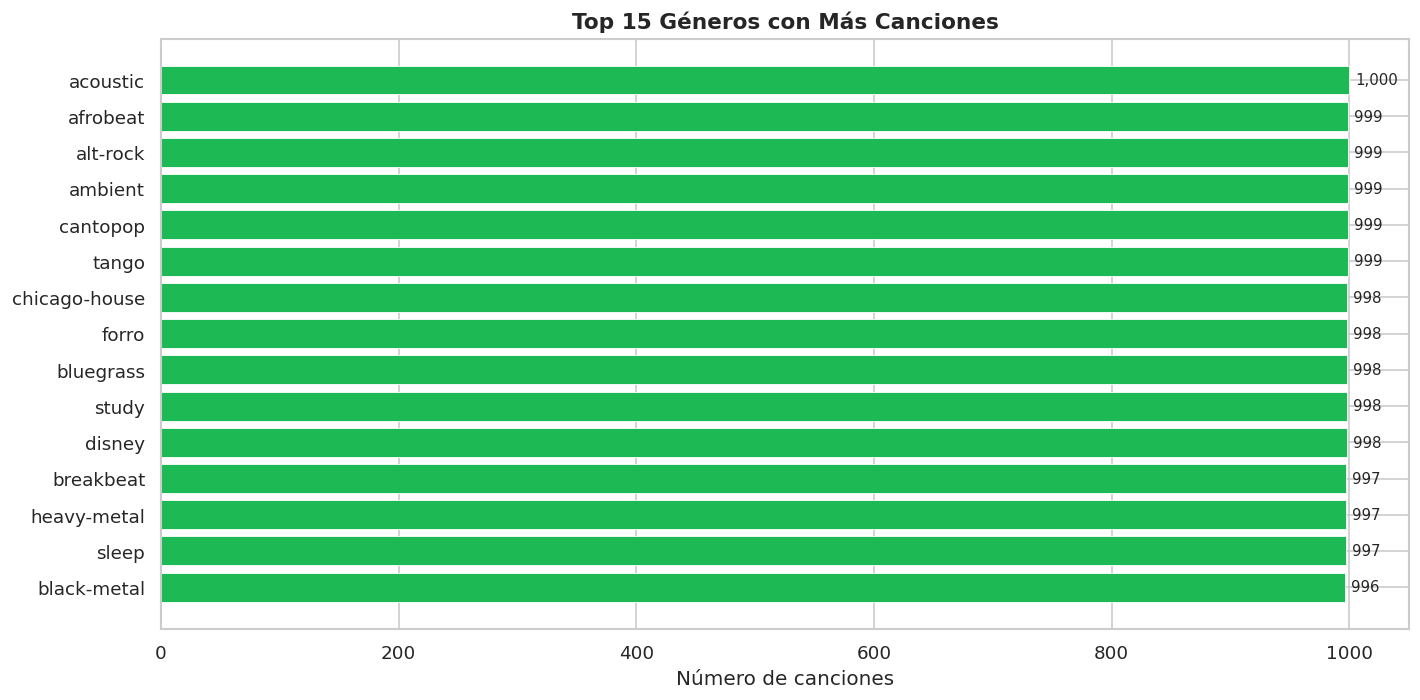

In [33]:
# Top 15 géneros con más canciones
top_generos = df['track_genre'].value_counts().head(15)
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top_generos.index[::-1], top_generos.values[::-1],
               color='#1DB954', edgecolor='white', linewidth=0.5)
ax.set_title('Top 15 Géneros con Más Canciones', fontsize=13, fontweight='bold')
ax.set_xlabel('Número de canciones')
for bar in bars:
    w = bar.get_width()
    ax.text(w + 5, bar.get_y() + bar.get_height()/2, f'{int(w):,}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('fig3_top_generos.png', bbox_inches='tight')
plt.show()

## 5. Análisis bivariado

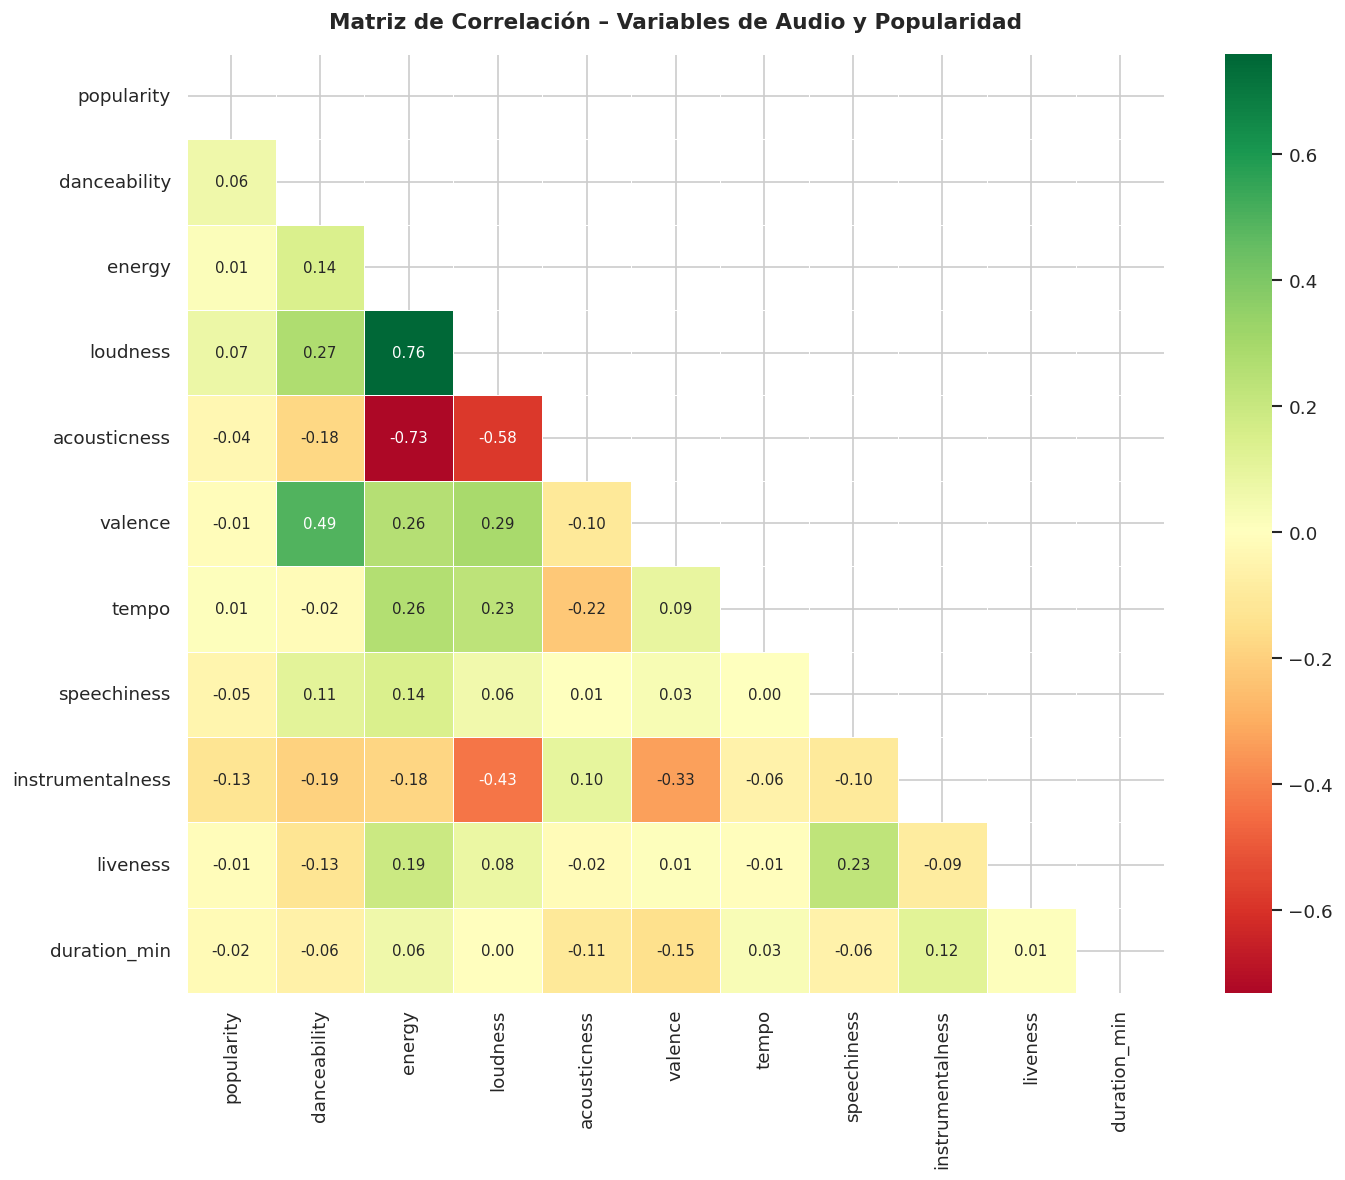

In [34]:
# Matriz de correlación
vars_corr = ['popularity','danceability','energy','loudness','acousticness',
             'valence','tempo','speechiness','instrumentalness','liveness','duration_min']

corr_matrix = df[vars_corr].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 9})
ax.set_title('Matriz de Correlación – Variables de Audio y Popularidad',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('fig4_correlacion.png', bbox_inches='tight')
plt.show()

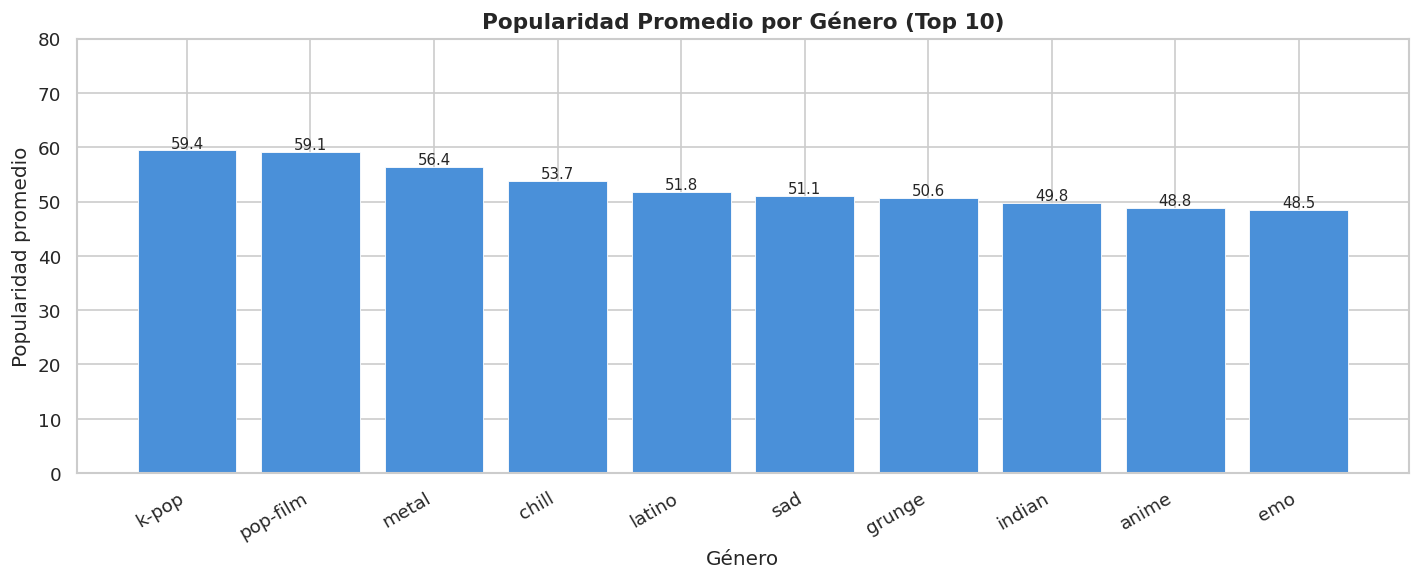

In [35]:
# Popularidad promedio por top 10 géneros
pop_genero = (df.groupby('track_genre')['popularity']
              .agg(['mean','count'])
              .query('count >= 200')
              .sort_values('mean', ascending=False)
              .head(10)
              .reset_index())

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(pop_genero['track_genre'], pop_genero['mean'],
              color='#4A90D9', edgecolor='white', linewidth=0.5)
ax.set_title('Popularidad Promedio por Género (Top 10)', fontsize=13, fontweight='bold')
ax.set_xlabel('Género')
ax.set_ylabel('Popularidad promedio')
ax.set_ylim(0, 80)
plt.xticks(rotation=30, ha='right')
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.5, f'{h:.1f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('fig5_pop_por_genero.png', bbox_inches='tight')
plt.show()

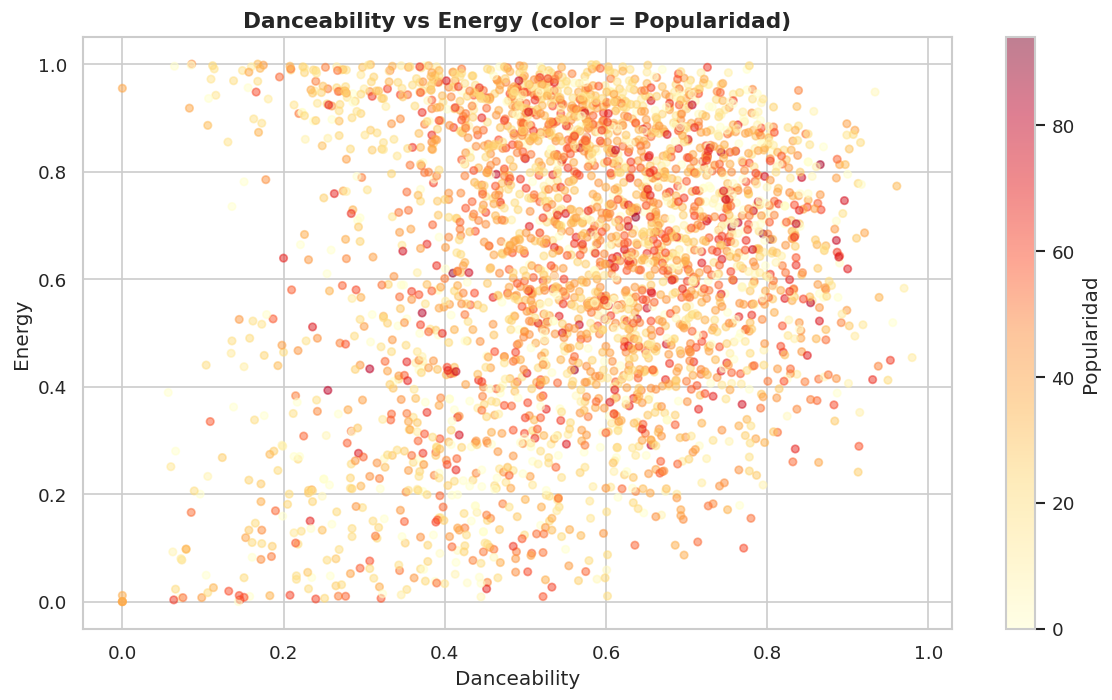

In [36]:
# Danceability vs Energy coloreado por popularidad
sample = df.sample(3000, random_state=42)
fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(sample['danceability'], sample['energy'],
                c=sample['popularity'], cmap='YlOrRd', alpha=0.5, s=20)
plt.colorbar(sc, ax=ax, label='Popularidad')
ax.set_title('Danceability vs Energy (color = Popularidad)', fontsize=13, fontweight='bold')
ax.set_xlabel('Danceability')
ax.set_ylabel('Energy')
plt.tight_layout()
plt.savefig('fig6_dance_energy.png', bbox_inches='tight')
plt.show()

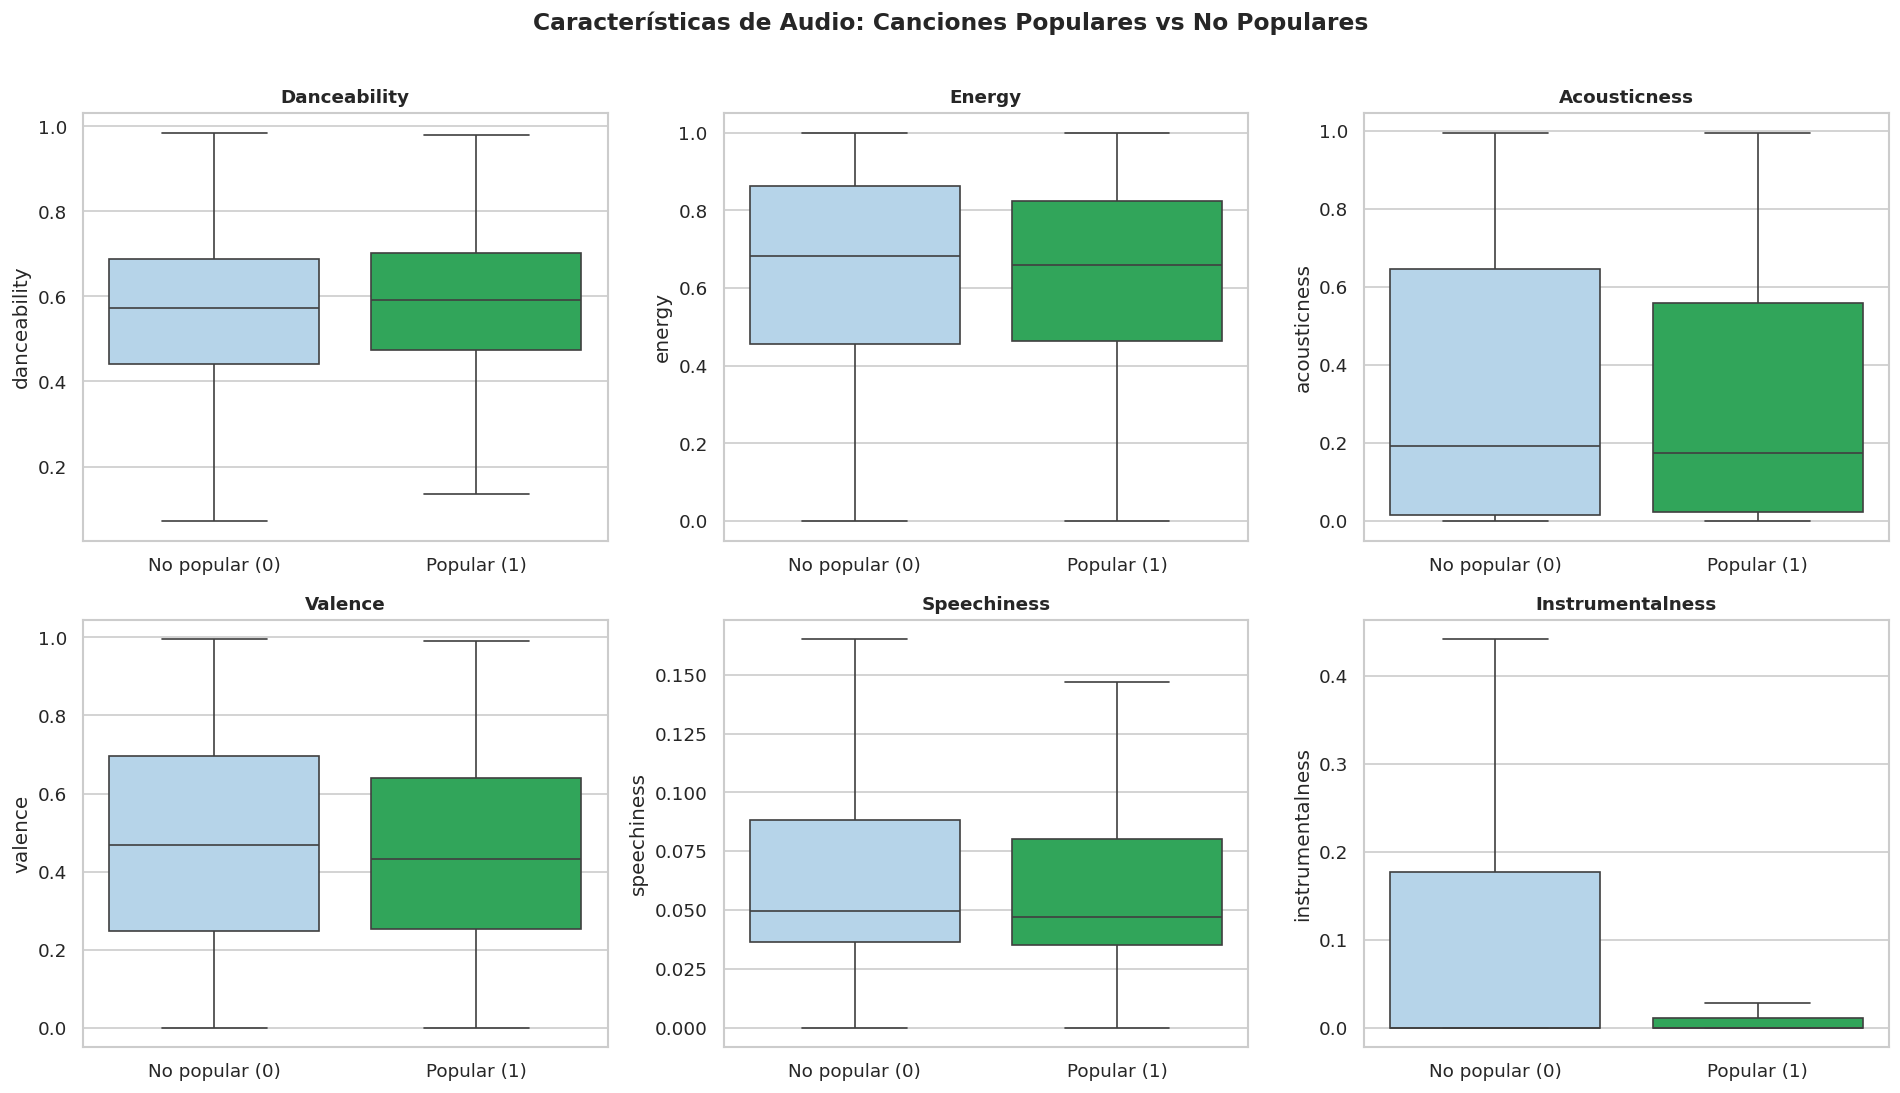

In [37]:
# Boxplot de características de audio: canciones populares vs no populares
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
palette = {'0': '#AED6F1', '1': '#1DB954'}

for i, var in enumerate(audio_vars):
    sns.boxplot(data=df, x='popular', y=var, palette=palette, ax=axes[i],
                showfliers=False)
    axes[i].set_title(var.capitalize(), fontsize=11, fontweight='bold')
    axes[i].set_xticklabels(['No popular (0)', 'Popular (1)'])
    axes[i].set_xlabel('')

plt.suptitle('Características de Audio: Canciones Populares vs No Populares',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig7_boxplot_popular.png', bbox_inches='tight')
plt.show()

## 6. Preparación para el modelo

In [38]:
# Variables predictoras y variable objetivo
features = ['danceability','energy','loudness','speechiness','acousticness',
            'instrumentalness','liveness','valence','tempo','duration_min',
            'explicit','key','mode','time_signature']

X = df[features].copy()
y = df['popular']

# Partición 80/20 estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Entrenamiento: {X_train.shape[0]:,} registros ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Prueba:        {X_test.shape[0]:,} registros ({X_test.shape[0]/len(X)*100:.1f}%)')
print(f'Balance en entrenamiento – No popular: {(y_train==0).sum():,} | Popular: {(y_train==1).sum():,}')

Entrenamiento: 71,792 registros (80.0%)
Prueba:        17,948 registros (20.0%)
Balance en entrenamiento – No popular: 54,825 | Popular: 16,967


## 7. Entrenamiento del modelo – Random Forest

In [39]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
print(f'Accuracy: {acc:.4f}')
print('\nReporte de Clasificación:')
print(classification_report(y_test, y_pred, target_names=['No popular','Popular']))

Accuracy: 0.6663

Reporte de Clasificación:
              precision    recall  f1-score   support

  No popular       0.85      0.69      0.76     13706
     Popular       0.37      0.60      0.46      4242

    accuracy                           0.67     17948
   macro avg       0.61      0.64      0.61     17948
weighted avg       0.73      0.67      0.69     17948



## 8. Métricas del modelo

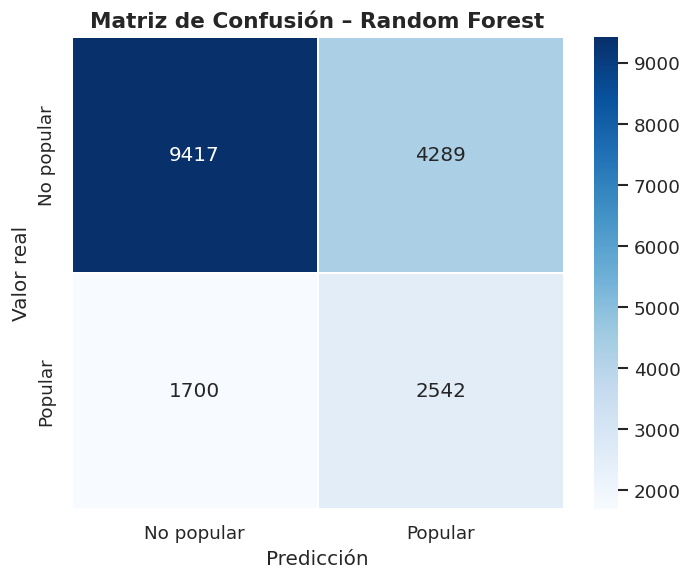

In [40]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['No popular','Popular'],
            yticklabels=['No popular','Popular'],
            linewidths=1, linecolor='white')
ax.set_title('Matriz de Confusión – Random Forest', fontsize=13, fontweight='bold')
ax.set_xlabel('Predicción')
ax.set_ylabel('Valor real')
plt.tight_layout()
plt.savefig('fig8_confusion_matrix.png', bbox_inches='tight')
plt.show()

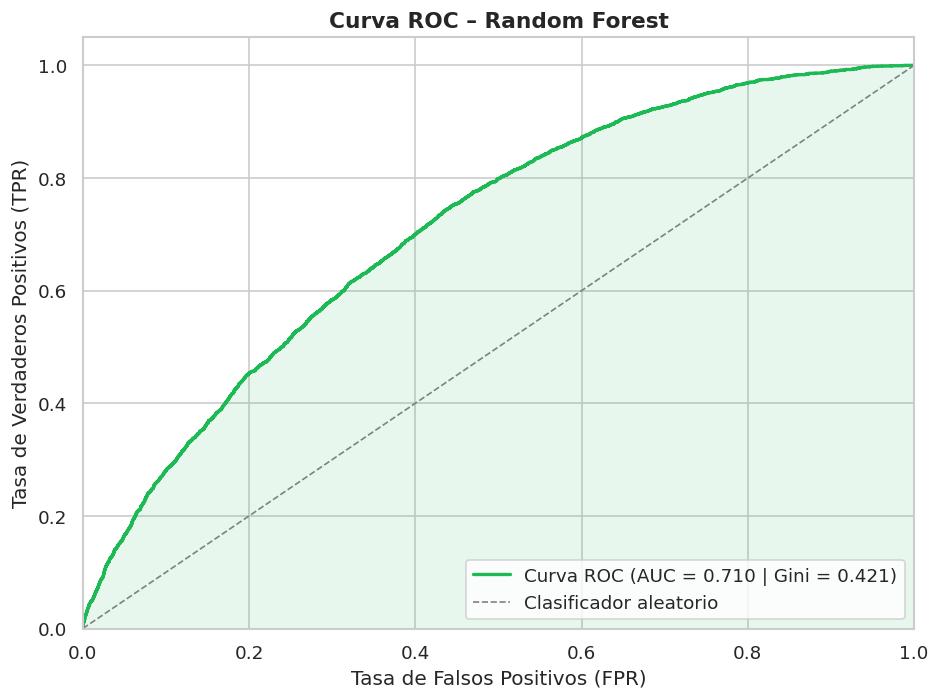

AUC-ROC: 0.7103
Gini:    0.4205


In [41]:
# Curva ROC y coeficiente Gini
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
gini = 2 * roc_auc - 1

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color='#1DB954', lw=2,
        label=f'Curva ROC (AUC = {roc_auc:.3f} | Gini = {gini:.3f})')
ax.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Clasificador aleatorio')
ax.fill_between(fpr, tpr, alpha=0.1, color='#1DB954')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('Tasa de Falsos Positivos (FPR)')
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)')
ax.set_title('Curva ROC – Random Forest', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('fig9_roc_curve.png', bbox_inches='tight')
plt.show()

print(f'AUC-ROC: {roc_auc:.4f}')
print(f'Gini:    {gini:.4f}')

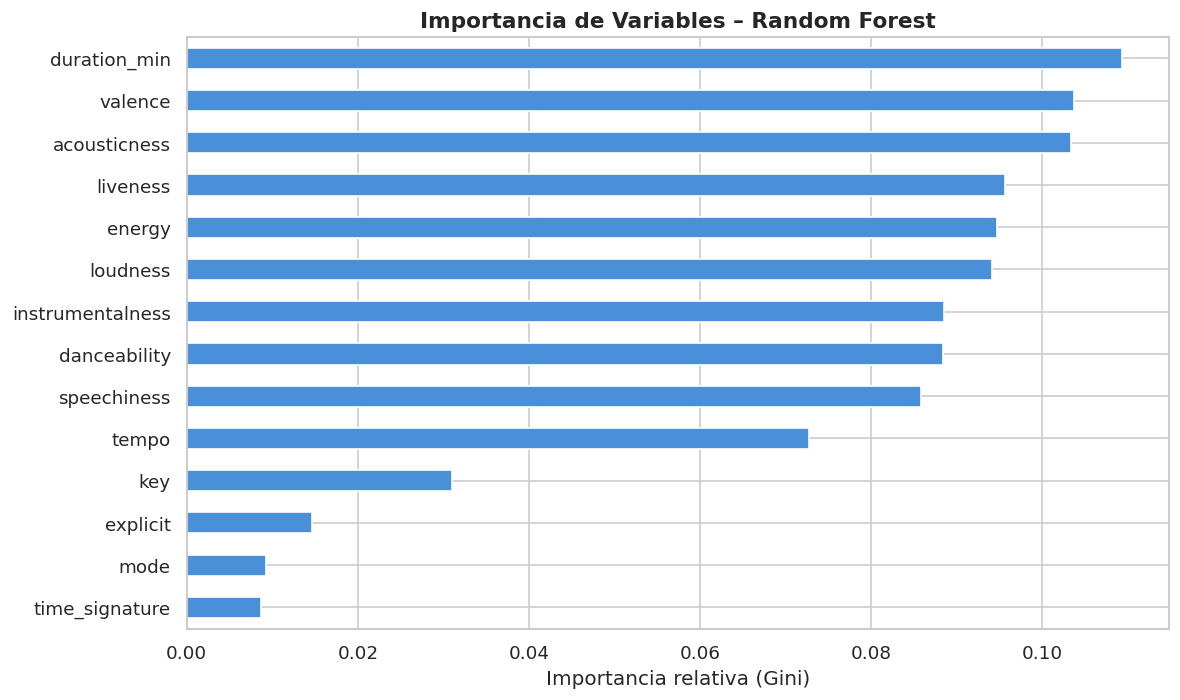

In [42]:
# Importancia de variables
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
importances.plot(kind='barh', color='#4A90D9', edgecolor='white', ax=ax)
ax.set_title('Importancia de Variables – Random Forest', fontsize=13, fontweight='bold')
ax.set_xlabel('Importancia relativa (Gini)')
plt.tight_layout()
plt.savefig('fig10_feature_importance.png', bbox_inches='tight')
plt.show()

## 9. Exportar dataset limpio y predicciones para Power BI

In [43]:
# Exportar dataset limpio
df_export = df.copy()
df_export.to_csv('spotify_clean.csv', index=False)
print(f'Dataset limpio exportado: {len(df_export):,} registros')

# Exportar predicciones del set de prueba
df_pred = X_test.copy()
df_pred['popular_real'] = y_test.values
df_pred['popular_predicho'] = y_pred
df_pred['prob_popular'] = y_prob
df_pred.to_csv('spotify_predicciones.csv', index=False)
print(f'Predicciones exportadas: {len(df_pred):,} registros')

# Resumen de métricas para Power BI
from sklearn.metrics import precision_score, recall_score, f1_score
metricas = pd.DataFrame({
    'Metrica': ['Accuracy','Precision','Recall','F1-Score','AUC-ROC','Gini'],
    'Valor': [
        round(accuracy_score(y_test, y_pred), 4),
        round(precision_score(y_test, y_pred), 4),
        round(recall_score(y_test, y_pred), 4),
        round(f1_score(y_test, y_pred), 4),
        round(roc_auc, 4),
        round(gini, 4)
    ]
})
metricas.to_csv('metricas_modelo.csv', index=False)
print('\nMétricas exportadas:')
print(metricas.to_string(index=False))

Dataset limpio exportado: 89,740 registros
Predicciones exportadas: 17,948 registros

Métricas exportadas:
  Metrica  Valor
 Accuracy 0.6663
Precision 0.3721
   Recall 0.5992
 F1-Score 0.4591
  AUC-ROC 0.7103
     Gini 0.4205


---
**Fin del EDA y entrenamiento del modelo**  
Los archivos generados son:
- `spotify_clean.csv` → dataset limpio para Power BI  
- `spotify_predicciones.csv` → predicciones del modelo para Power BI  
- `metricas_modelo.csv` → resumen de métricas para tarjetas KPI en Power BI  
- `fig1_distribuciones.png` a `fig10_feature_importance.png` → gráficos para el informe